In [ ]:
!nvidia-smi

Sat Sep  9 17:14:38 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   67C    P8    12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 2s 0us/step


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
clasificador_cnn = keras.models.Sequential([
    keras.layers.Conv2D(32, 7, activation="relu", padding="same",
                       input_shape=[32,32,3]),
    BatchNormalization(synchronized=True),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    BatchNormalization(synchronized=True),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [ ]:
clasificador_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        4736      
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 16)        4624      
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 16)        64        
 chNormalization)                                                
                                                        

In [ ]:
clasificador_cnn.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
h = clasificador_cnn.fit(x_train, y_train, epochs=30, batch_size=1000, validation_split = 0.2)

Epoch 1/30
40/40 [==============================] - 20s 55ms/step - loss: 2.2999 - accuracy: 0.1488 - val_loss: 2.2684 - val_accuracy: 0.1573
Epoch 2/30
40/40 [==============================] - 2s 45ms/step - loss: 2.0168 - accuracy: 0.2554 - val_loss: 2.1135 - val_accuracy: 0.2546
Epoch 3/30
40/40 [==============================] - 2s 45ms/step - loss: 1.8711 - accuracy: 0.3117 - val_loss: 1.9570 - val_accuracy: 0.2916
Epoch 4/30
40/40 [==============================] - 2s 45ms/step - loss: 1.7798 - accuracy: 0.3757 - val_loss: 1.8095 - val_accuracy: 0.3556
Epoch 5/30
40/40 [==============================] - 2s 46ms/step - loss: 1.7025 - accuracy: 0.4017 - val_loss: 1.7895 - val_accuracy: 0.3637
Epoch 6/30
40/40 [==============================] - 2s 47ms/step - loss: 1.6350 - accuracy: 0.4242 - val_loss: 1.6837 - val_accuracy: 0.4127
Epoch 7/30
40/40 [==============================] - 2s 47ms/step - loss: 1.5653 - accuracy: 0.4639 - val_loss: 1.6558 - val_accuracy: 0.4277
Epoch 8/30
4

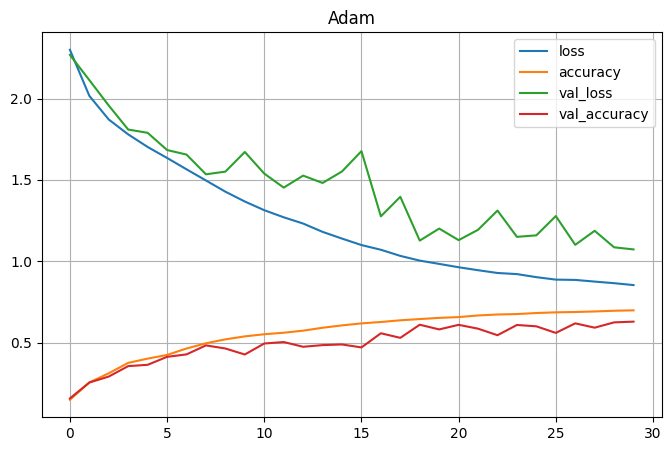

In [ ]:
pd.DataFrame(h.history).plot(figsize=(8, 5))
plt.title('Adam')
plt.grid(True)
plt.show()

In [ ]:
predictions = clasificador_cnn.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [ ]:
def one_hot_vector(vec):
  max_idx = -1
  max_element = -1
  for i in range(len(vec)):
    if vec[i] > max_element:
      max_idx = i
      max_element = vec[i]
  ohv = np.zeros( len(vec) )
  ohv[max_idx] = 1
  return ohv

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


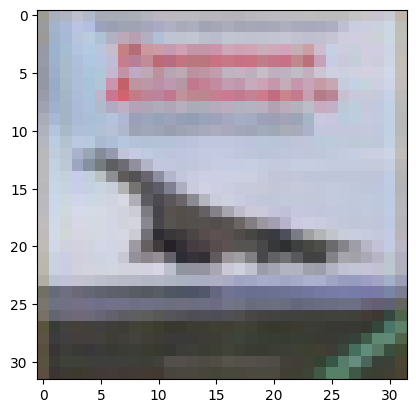

In [ ]:
img_input_id = 3
ohv = one_hot_vector( predictions[img_input_id] )
print( ohv )
print( y_test[img_input_id] )
plt.imshow( x_test[img_input_id] );